## goal of this notebook

Load the layers output for G and for J for a single monthly mean.

Things will crash and I want to be able to load this quickly. First let's verify the gates such that our mask is correct.

In [1]:
# we had a function previously to get the Gterms 

# import the packages

# auto-reload edited modules
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.insert(0, "/home/mmurakami/crios_backups/an_helper_functions")

# run the script into the current kernel (vars/functions become available)
%run -i "/home/mmurakami/crios_backups/an_helper_functions/load_packages.py"

(50,) (50, 1350, 270)
hf1 (1350, 270)
(1, 1350, 270)
LwetC2d 146614
LwetC 4833023



In [2]:
# set the correct directories based on official ASTE
forward_path = "/scratch/atnguyen/aste_270x450x180/OFFICIAL_ASTE_R1_Sep2019/"
dirdiags = "/scratch/atnguyen/aste_270x450x180/OFFICIAL_ASTE_R1_Sep2019/diags/BUDG/"
dirstate = "/scratch/atnguyen/aste_270x450x180/OFFICIAL_ASTE_R1_Sep2019/diags/STATE/"

# layers path here is for what time steps?
layers_path2007 = "/scratch3/atnguyen/aste_270x450x180/run_c68v_layers_lessmem1_adxOFF_Jan2007_capxxN50_it0062_pk0000262944_bro/"
layers_path2016 = "/scratch3/atnguyen/aste_270x450x180/run_c68v_layers_lessmem1_adxOFF_Jan2016_capxxN50_it0062_pk0000736272_bro/"
layers_path = "/scratch3/atnguyen/aste_270x450x180/run_c68v_layers_lessmem1_adxOFF_Jan2007_capxxN50_it0062_pk0000262944_bro/"


In [3]:
# use validated mask in the other file
mymsk[:,84:110] = np.nan

In [4]:
# plt.pcolormesh(mymsk)
mymsk = np.zeros((ny,nx))
mymsk[500,20] = 1
mymsk[mymsk==0] = np.nan

In [5]:
iwet_mine = get_iwet_from_mymsk(mymsk,iwetC2d)

In [6]:
# let's move the gate calculation to a function to show a timeseries
# define tstep 
dt_aste = 600
startyr = 2002
endyr = 2019

# all the filenames in the system
fnames = get_fnames(dt_aste,startyr,endyr)

times = {}
times['2007'] = np.arange(3,5,1)
print(times)

# the filenames we want for 2014
tsstr,datetimes = get_tsteps(times,fnames,dt_aste,startyr,1,1)
tsstr

{'2007': array([3, 4])}


array(['0000271440', '0000275904'], dtype='<U32')

In [7]:
# we're doing March of 2007 now for layers and offline version

## Load and save the G terms

In [8]:
iwet_mine

array([57439])

In [9]:
# --- Load original edges to get bounds only ---
_T_edges_raw = rdmds(layers_path + "layers2TH").reshape(-1)
_S_edges_raw = rdmds(layers_path + "layers1SLT").reshape(-1)

#T_edges = np.linspace(_T_edges_raw[0], _T_edges_raw[-1], nT + 1)                             # boundsT
#S_edges = np.linspace(_S_edges_raw[0], _S_edges_raw[-1], nS + 1)                             # boundsS
T_edges = _T_edges_raw
S_edges = _S_edges_raw
boundsT,boundsS = T_edges,S_edges
nT,nS = 112,112

# --- Everything else derived programmatically ---
T_centers      = 0.5 * (T_edges[:-1] + T_edges[1:])                                          # binmidT, binsTH_centers
S_centers      = 0.5 * (S_edges[:-1] + S_edges[1:])                                          # binmidS, binsSLT_centers
binmidT = T_centers
binmidS = S_centers

dT_edges       = T_edges[1:] - T_edges[:-1]                                                  # binwidthT
dS_edges       = S_edges[1:] - S_edges[:-1]                                                  # binwidthS

# these are the points we normalize for the J term --  i
dT_centers     = 0.5 * (dT_edges[:-1] + dT_edges[1:])                                        # binwidthT1
dS_centers     = 0.5 * (dS_edges[:-1] + dS_edges[1:])                                        # binwidthS1
binwidthT1 = dT_centers
binwidthS1 = dS_centers

T_inner_edges  = T_edges[1:-1]                                                               # binmidTp
S_inner_edges  = S_edges[1:-1]                                                               # binmidSp

T_edges_2d,       S_edges_2d       = np.meshgrid(T_edges,       S_edges)
T_centers_2d,     S_centers_2d     = np.meshgrid(T_centers,     S_centers)
T_inner_edges_2d, S_inner_edges_2d = np.meshgrid(T_inner_edges, S_inner_edges)

dT_3d, dS_3d = np.meshgrid(dT_edges, dS_edges)
dT_3d = dT_3d.reshape(nS, nT, 1)
dS_3d = dS_3d.reshape(nS, nT, 1)

# set the mesh for plotting
binmidTp = T_edges[1:-1]
binmidSp = S_edges[1:-1]
Tbin2,Sbin2 = np.meshgrid(binmidTp,binmidSp) # for plotting the J terms individually as vectors!
bincentTp = T_centers[1:-1]
bincentSp = S_centers[1:-1]
Sbin3,Tbin3 = Sbin2[1:-1,1:-1],Tbin2[1:-1,1:-1]    # this is now correct, should be same placement as edges but -1 on both ends

In [10]:
# 2d
rac2d = read_float64(dirgridw + "RAC_" + str(LwetC2d) + ".data")
print("RAC2d",rac2d.shape)

drf3d = read_float32(dirgridw + "DRF_" + str(LwetC) + ".data")

hf1flat = np.reshape(hf1,hf1.flatten().shape[0])
hf2d = hf1flat[iwetC2d]

rac2dtile = np.tile(rac2d,(nT-1,1)) #.shape
hf2dtile = np.tile(hf2d,(nT-1,1))
ffac = 1e-6

RAC2d (146614,)
(4833023,)


In [11]:
ffac=1e-6
G_T=np.array([])
metaT=parsemeta(layers_path + "diags/LAYERS/layers_3d_Ttend." + str(tsstr[-1])+ ".meta")
metaS=parsemeta(layers_path + "diags/LAYERS/layers_3d_Stend." + str(tsstr[-1])+ ".meta")
nFldsS = metaS["fldList"]
nFldsT = metaT["fldList"]
print(len(nFldsS))
print(len(nFldsT))
setTtend=nFldsT.copy()
setStend=nFldsS.copy()

24
24


In [12]:
# check for the correct diagnostics
metaS['fldList']
a = metaS['fldList']
# print(a[12],a[13],a[14],a[19],a[20],a[23])  # surf 
ifldS = np.array([12,13,14,19,20,23])  # total tend, surf, hDiff, vDiff, hADV, vADV

metaT['fldList']   # 13, 14, 15, 16, 19, 22
b = metaT['fldList']
# print(b[0],b[1],b[2],b[7],b[8],b[11])
ifldT = np.array([0,1,2,7,8,11])    # surf, hDiff, vDiff, hADV, vADV, total tend

print(np.array(a)[ifldS]) # for G_S
print()
print(np.array(b)[ifldT]) # for G_T

['LaSs1SLT' 'LaSh1SLT' 'LaSz1SLT' 'LSha1SLT' 'LSza1SLT' 'LSto1SLT']

['LaTs2TH' 'LaTh2TH' 'LaTz2TH' 'LTha2TH' 'LTza2TH' 'LTto2TH']


## Load and save the G_T terms for this timestep

In [13]:
# test this for a single point first

In [14]:
# make the G_T term
G_T = {}
name = "BarentsS"
G_T[name] = {}
    
# now loop through
for ts in tsstr:
    G_T[name][ts] = {}
    for i in range(len(ifldT)-1, -1, -1):
        tmp = read_float32_skip(layers_path + "diags/LAYERS/layers_3d_Ttend." + tsstr[-1] + ".data", nx*ny*(nT-1),ifldT[i])
        tmp = np.reshape(tmp,(nT-1,nx*ny))
        tmp = tmp[:,iwetC2d] * (rac2dtile * hf2dtile) * ffac
        if i == ifldT.shape[0]-1:
            # if LTto2TH, do not remove from residual
            residT = tmp
        else:
            # else if vADV, hADV, vDiff, hDiff, surface, remove from residual
            residT = residT-tmp
    
        # just do the Barents Sea for this one
        a = np.nansum(tmp[:,iwet_mine],axis=1)
        G_T[name][ts][setTtend[ifldT[i]]] = a

    G_T[name][ts]["residT"] = np.nansum(residT[:,iwet_mine],axis=1)

In [15]:
G_T[name][tsstr[0]].keys()

dict_keys(['LTto2TH', 'LTza2TH', 'LTha2TH', 'LaTz2TH', 'LaTh2TH', 'LaTs2TH', 'residT'])

In [16]:
# quickly load G terms and validate, then continue

In [ ]:
from create_aste270_layers import create_layersTHETA
MsumT,termsT3D,dF_Tnew = create_layersTHETA(tsstr,mygrid,myparms,dirdiags,dirstate,layers_path,mymsk,nz,ny,nx,nfx,nfy,dt)

In [ ]:
fig = plt.figure()
xt = boundsT.flatten()[1:-1]
plt.plot(xt,dF_Tnew[0]/binwidthT1*1e-6)
plt.plot(xt,G_T[name][tsstr[1]]["LTha2TH"])

In [ ]:
fig = plt.figure()
xt = boundsT.flatten()[1:-1]
plt.plot(xt,dF_Tnew[4]/binwidthT1*1e-6)
plt.plot(xt,G_T[name][tsstr[1]]["LaTs2TH"])

In [ ]:
t2 = int(tsstr[1])
file_name = "state_3d_set1"
meta_state_3d_set1 = parsemeta(dirstate + file_name + "." + tsstr[0] + ".meta")
fldlist = np.array(meta_state_3d_set1["fldList"])
varnames = np.array(["THETA","SALT"])
recs = np.array([])
for var in varnames:
    irec = np.where(fldlist == var)
    recs = np.append(recs, irec[0][0])
THETA,its,meta = rdmds(os.path.join(dirstate, file_name),t2,returnmeta=True,rec=recs[0])
SALT,its,meta = rdmds(os.path.join(dirstate, file_name),t2,returnmeta=True,rec=recs[1])

THETA = THETA.reshape(nz, ny, nx)
SALT  = SALT.reshape(nz, ny, nx)

In [ ]:
THETA[0,500,20]

In [ ]:
binmidT[12:15]

In [ ]:
np.where(G_T[name][tsstr[1]]["LaTs2TH"]<0)

In [ ]:
np.where(dF_Tnew[4]<0)

In [ ]:
layers_path

In [ ]:
t2 = int(tsstr[1])
file_name = "state_3d_set1"


meta_state_3d_set1 = parsemeta(layers_path + "diags/STATE/" + file_name + "." + tsstr[0] + ".meta")
fldlist = np.array(meta_state_3d_set1["fldList"])
varnames = np.array(["THETA","SALT"])
recs = np.array([])
for var in varnames:
    irec = np.where(fldlist == var)
    recs = np.append(recs, irec[0][0])
THETA,its,meta = rdmds(os.path.join(layers_path + "diags/STATE/", file_name),t2,returnmeta=True,rec=recs[0])
SALT,its,meta = rdmds(os.path.join(layers_path + "diags/STATE/", file_name),t2,returnmeta=True,rec=recs[1])

THETA = THETA.reshape(nz, ny, nx)
SALT  = SALT.reshape(nz, ny, nx)

In [ ]:
THETA[0,500,20]

## Ok, we just verified that this will in fact be binned at a different THETA in space

In [1]:
# return to creating the G term as requested
# we had a function previously to get the Gterms 

# import the packages

# auto-reload edited modules
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.insert(0, "/home/mmurakami/crios_backups/an_helper_functions")

# run the script into the current kernel (vars/functions become available)
%run -i "/home/mmurakami/crios_backups/an_helper_functions/load_packages.py"

(50,) (50, 1350, 270)
hf1 (1350, 270)
(1, 1350, 270)
LwetC2d 146614
LwetC 4833023



In [2]:
mymsk[:,84:110] = np.nan

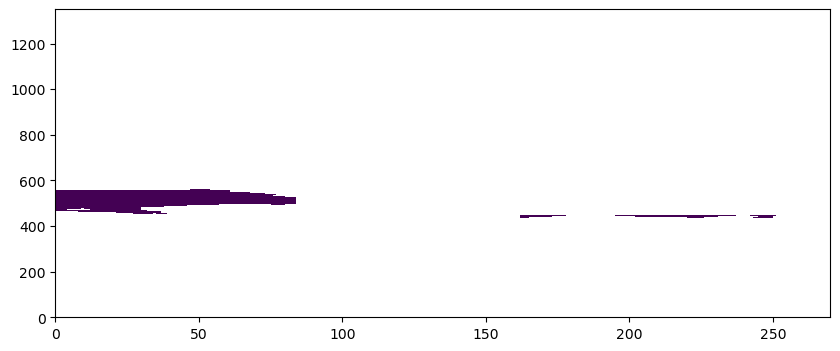

In [3]:
plt.pcolormesh(mymsk)

In [4]:
iwet_mine = get_iwet_from_mymsk(mymsk,iwetC2d)

In [164]:
# make the G_T term
G_T = {}
name = "BarentsS"
G_T[name] = {}
    
# now loop through
for ts in tsstr:
    G_T[name][ts] = {}
    for i in range(len(ifldT)-1, -1, -1):
        tmp = read_float32_skip(layers_path + "diags/LAYERS/layers_3d_Ttend." + tsstr[-1] + ".data", nx*ny*(nT-1),ifldT[i])
        tmp = np.reshape(tmp,(nT-1,nx*ny))
        tmp = tmp[:,iwetC2d] * (rac2dtile * hf2dtile) * ffac
        if i == ifldT.shape[0]-1:
            # if LTto2TH, do not remove from residual
            residT = tmp
        else:
            # else if vADV, hADV, vDiff, hDiff, surface, remove from residual
            residT = residT-tmp
    
        # just do the Barents Sea for this one
        a = np.nansum(tmp[:,iwet_mine],axis=1)
        G_T[name][ts][setTtend[ifldT[i]]] = a

    G_T[name][ts]["residT"] = np.nansum(residT[:,iwet_mine],axis=1)

In [165]:
# create G_S for all basins (line 258)
G_S = {}
G_S[name] = {}

# now loop through similar to ifldS
for i in range(len(ifldS)-1, -1, -1):
    tmp = read_float32_skip(layers_path + "diags/LAYERS/layers_3d_Stend." + tsstr[-1] + ".data", nx*ny*(nT-1),ifldS[i])
    tmp = np.reshape(tmp,(nS-1,nx*ny))
    tmp = tmp[:,iwetC2d] * (rac2dtile * hf2dtile) * ffac
    if i == ifldS.shape[0]-1:
        # if LSto1SLT, do not remove from residual, this is the total tendency
        residS = tmp
    else:
        # else if vADV, hADV, vDiff, hDiff, surface, remove from residual
        residS = residS-tmp

    # just do for the Barents Sea
    a = np.nansum(tmp[:,iwet_mine],axis=1)
    G_S[name][setStend[ifldS[i]]] = a

# loop through again to calculate resid
G_S[name]["residS"] = np.nansum(residS[:,iwet_mine],axis=1)

In [166]:
# save these 
import os
import pickle

save_dir = "/scratch/mmurakami/ASTE_270/ASTER1_online_layers"
os.makedirs(save_dir, exist_ok=True)

# file paths
g_t_file = os.path.join(save_dir, "G_T.pkl")
g_s_file = os.path.join(save_dir, "G_S.pkl")

# save
with open(g_t_file, "wb") as f:
    pickle.dump(G_T, f, protocol=pickle.HIGHEST_PROTOCOL)

with open(g_s_file, "wb") as f:
    pickle.dump(G_S, f, protocol=pickle.HIGHEST_PROTOCOL)

print("Saved to:")
print(g_t_file)
print(g_s_file)

Saved to:
/scratch/mmurakami/ASTE_270/ASTER1_online_layers/G_T.pkl
/scratch/mmurakami/ASTE_270/ASTER1_online_layers/G_S.pkl


In [167]:
# load them back
save_dir = "/scratch/mmurakami/ASTE_270/ASTER1_online_layers"

g_t_file = os.path.join(save_dir, "G_T.pkl")
g_s_file = os.path.join(save_dir, "G_S.pkl")

with open(g_t_file, "rb") as f:
    G_T_loaded = pickle.load(f)

with open(g_s_file, "rb") as f:
    G_S_loaded = pickle.load(f)

print(G_T_loaded.keys())
print(G_S_loaded.keys())

dict_keys(['BarentsS'])
dict_keys(['BarentsS'])


## create and save the J terms from online

In [5]:
# check the lists
# read the fieldlists from the setTS_Stend_set1 and 2
# metaT=parsemeta(dirdiags + "LAYERS/layers_3d_Ttend.0000723024.meta")

# set 1 - the total terms we want for the budget
setTS_Ttend=parsemeta(layers_path + "diags/LAYERS_Cwet/layers_TSjoint_Ttend_set1_146614.0000315504.meta")["fldList"]

# set 2 - the other terms
setTS_Ttend_set2=parsemeta(layers_path + "diags/LAYERS_Cwet/layers_TSjoint_Ttend_set2_146614.0000315504.meta")["fldList"]

# set 1 - the total terms for the salt budget
setTS_Stend=parsemeta(layers_path + "diags/LAYERS_Cwet/layers_TSjoint_Stend_set1_146614.0000315504.meta")["fldList"]

# set 2 - the other terms
setTS_Stend_set2=parsemeta(layers_path + "diags/LAYERS_Cwet/layers_TSjoint_Stend_set2_146614.0000315504.meta")["fldList"]

NameError: name 'layers_path' is not defined

In [ ]:
# Load the saved NPZ file
matname = "/scratch/mmurakami/ASTE_270/ASTER1_online_layers/Jy.npz"

loaded_data = np.load(matname, allow_pickle=True)

# Convert to a standard dictionary
loaded_dict = {key: loaded_data[key].item() if loaded_data[key].ndim == 0 else loaded_data[key]
               for key in loaded_data}

# Reconstruct the nested dictionary
def unflatten_dict(d, sep='/'):
    """ Rebuild a nested dictionary from a flattened dictionary """
    unflat_dict = {}
    for key, value in d.items():
        parts = key.split(sep)
        d_ref = unflat_dict
        for part in parts[:-1]:
            d_ref = d_ref.setdefault(part, {})
        d_ref[parts[-1]] = value
    return unflat_dict

Jy_loaded = unflatten_dict(loaded_dict)

# Verify structure
print(Jy_loaded)


In [ ]:
matname = "/scratch/mmurakami/ASTE_270/ASTER1_online_layers/Jx.npz"

loaded_data = np.load(matname, allow_pickle=True)

# Convert to a standard dictionary
loaded_dict = {key: loaded_data[key].item() if loaded_data[key].ndim == 0 else loaded_data[key]
               for key in loaded_data}

Jx_loaded = unflatten_dict(loaded_dict)

# Verify structure
print(Jx_loaded)
